<h1 align='center'> Plots de Paridade - Dispersão de Fônons MLFF vs Diferenças Finitas </h1>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def read_bands(filename: str):
    with open(filename, "r") as f:
        lines: list[str] = f.readlines()

    labels: list[str] = lines[0].strip().split()[1:]
    points = np.array(lines[1].strip().split()[1:], dtype=float)

    data = np.loadtxt(filename, comments="#")
    x = data[:, 0]
    bands = data[:, 1:]

    return labels, points, x, bands


## Sem a inclusão dos modos normais

In [3]:
# Ler os arquivos
labels1, points1, x1, bands1 = read_bands(
    r"../alamode_phonons/01_qe_finite_diff/LDA/zno222_NA3.bands"
)
_, _, _, bands2 = read_bands(
    r"../alamode_phonons/03_mlff_aenetpytorch/LDA/model001/zno_lda_aenet.bands"
)


In [4]:
print(bands1.shape)
print(bands2.shape)


(246, 12)
(246, 12)


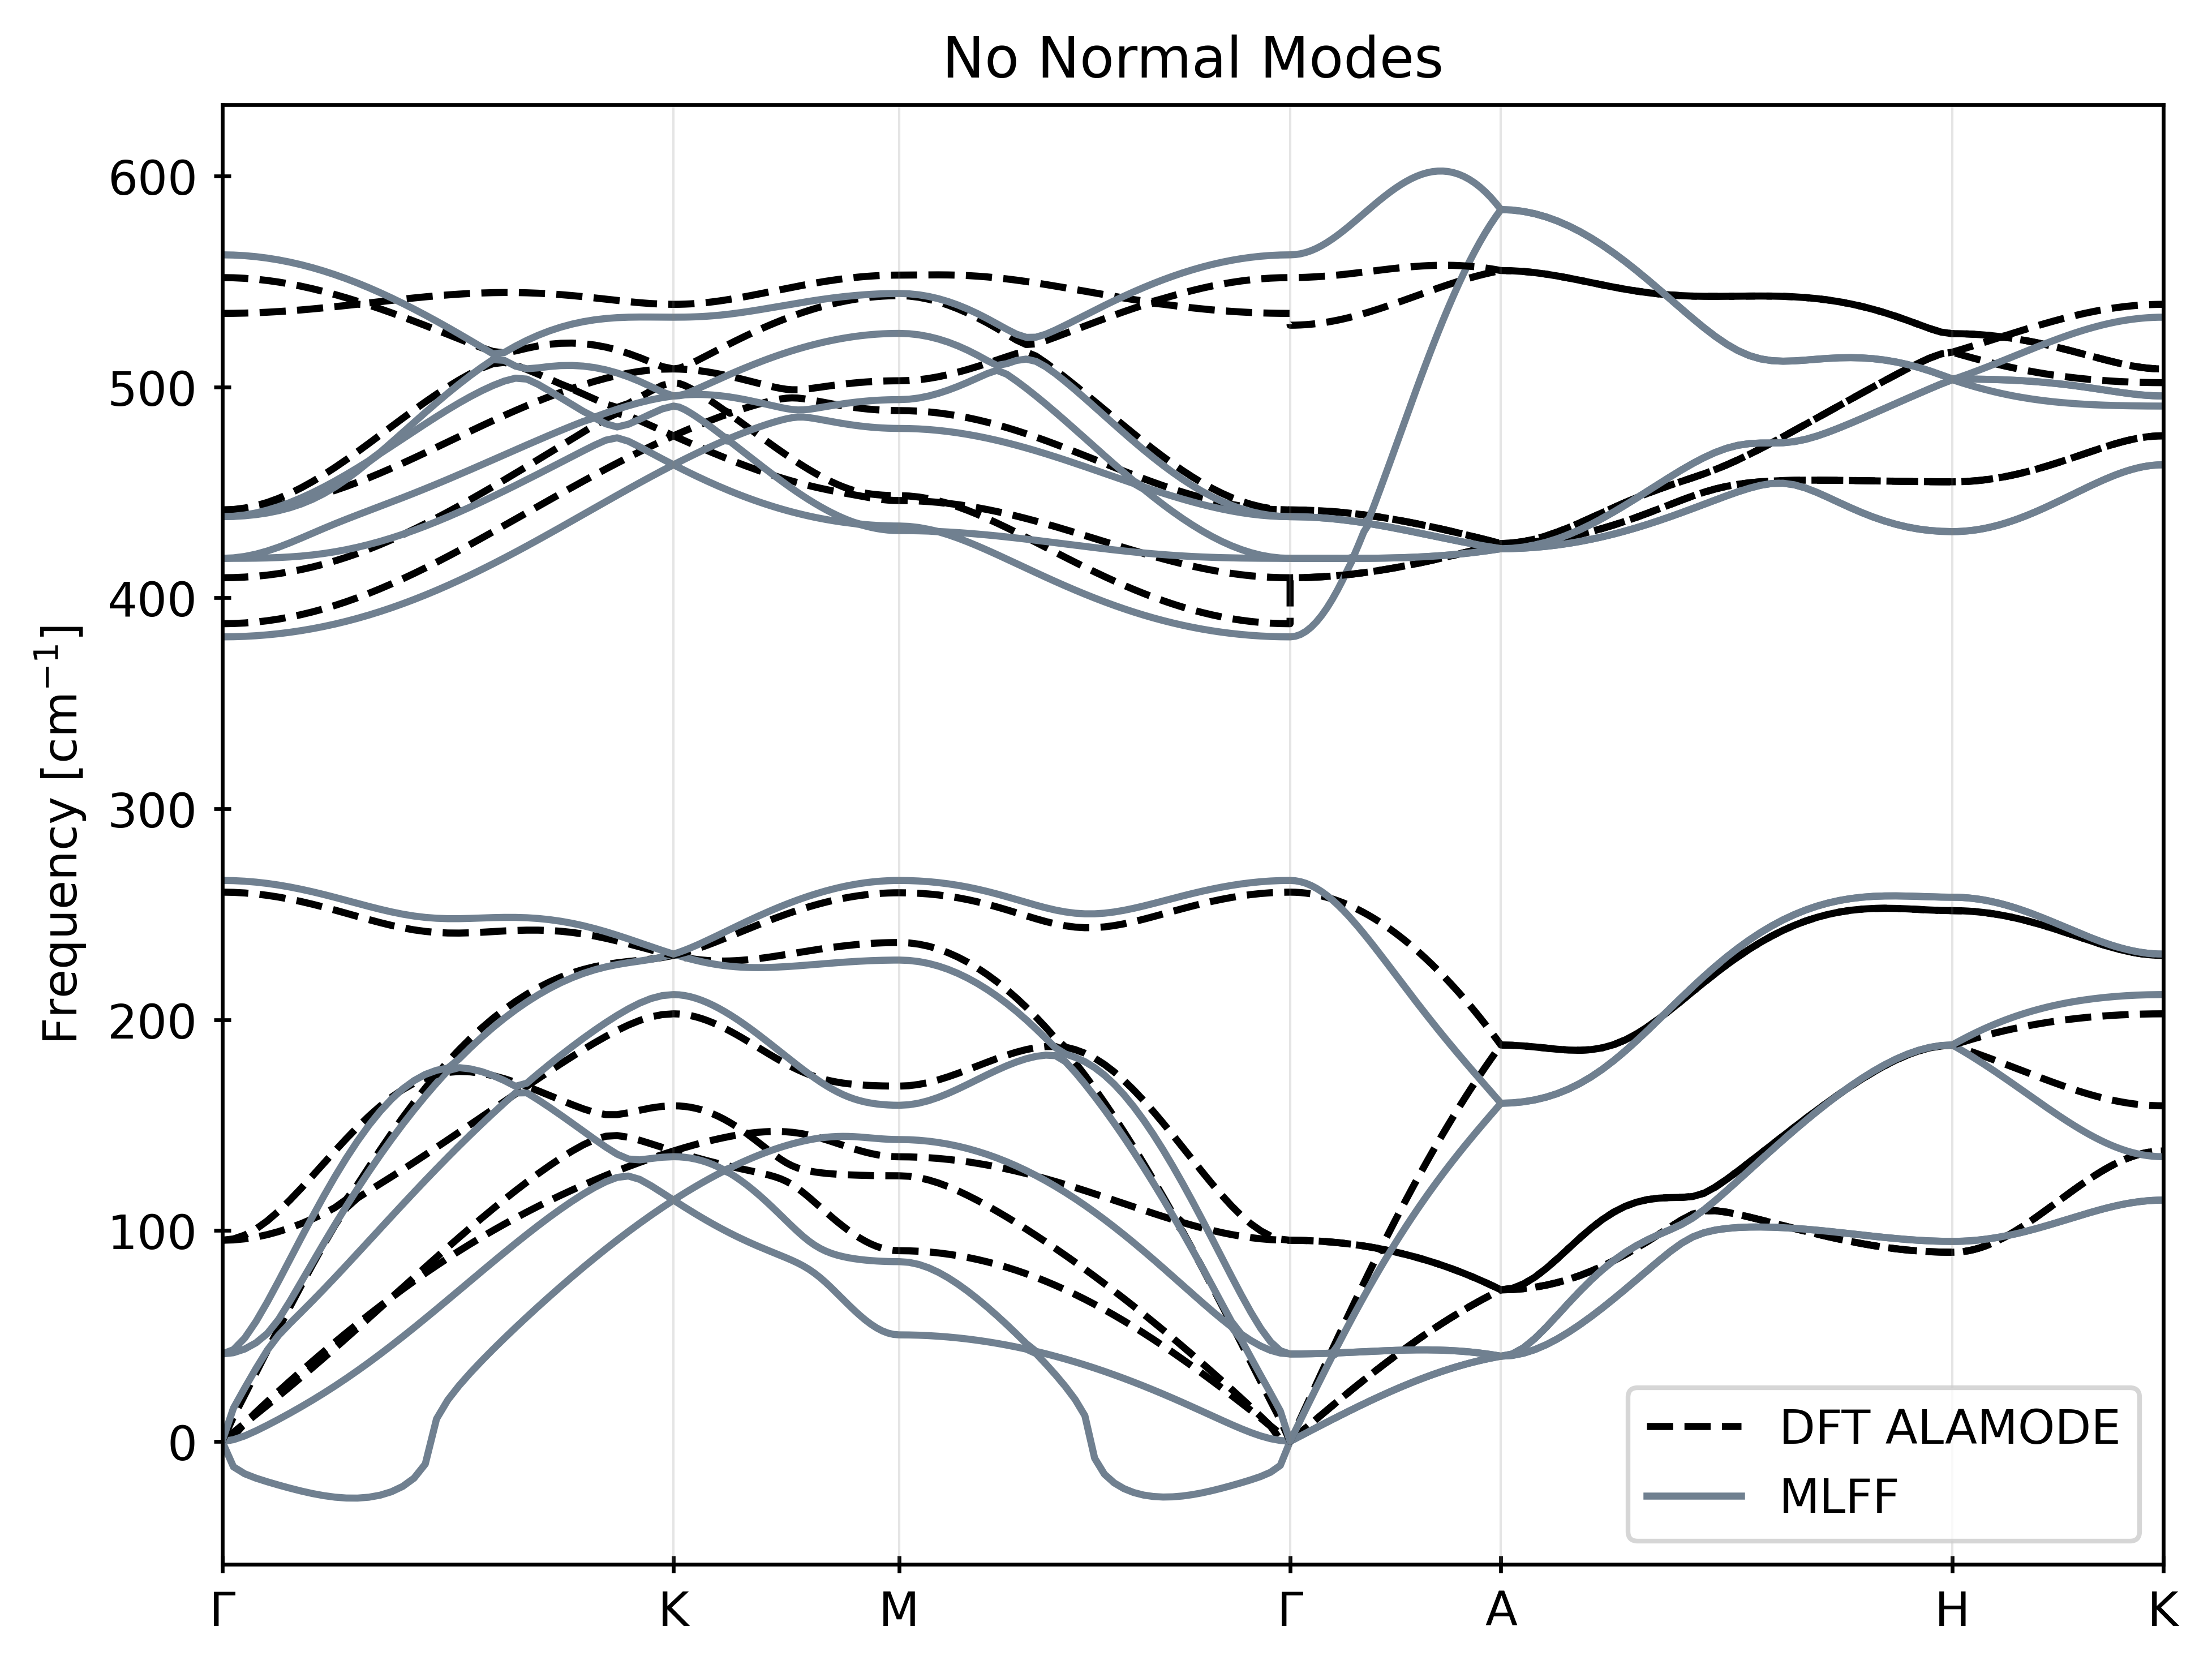

In [5]:
NBANDS = bands1.shape[1]
labels = [r"$\Gamma$" if label == "G" else label for label in labels1]

fig, ax = plt.subplots(dpi=600, layout="constrained")
ax.set_title("No Normal Modes")
ax.tick_params(direction="inout")
ax.set(
    xticks=points1,
    xticklabels=labels,
    xlim=(points1[0], points1[-1]),
    ylabel=r"Frequency [cm$^{-1}$]",
)

for q in range(NBANDS):
    label = "DFT ALAMODE" if q == 0 else ""
    ax.plot(x1, bands1[:, q], color="k", ls="--", label=label)
    label = "MLFF" if q == 0 else ""
    ax.plot(x1, bands2[:, q], color="slategray", ls="-", label=label)

for p in points1:
    ax.axvline(p, color="gray", ls="-", lw=0.5, alpha=0.2)
ax.legend()
plt.show()

# Adicionando modos normais

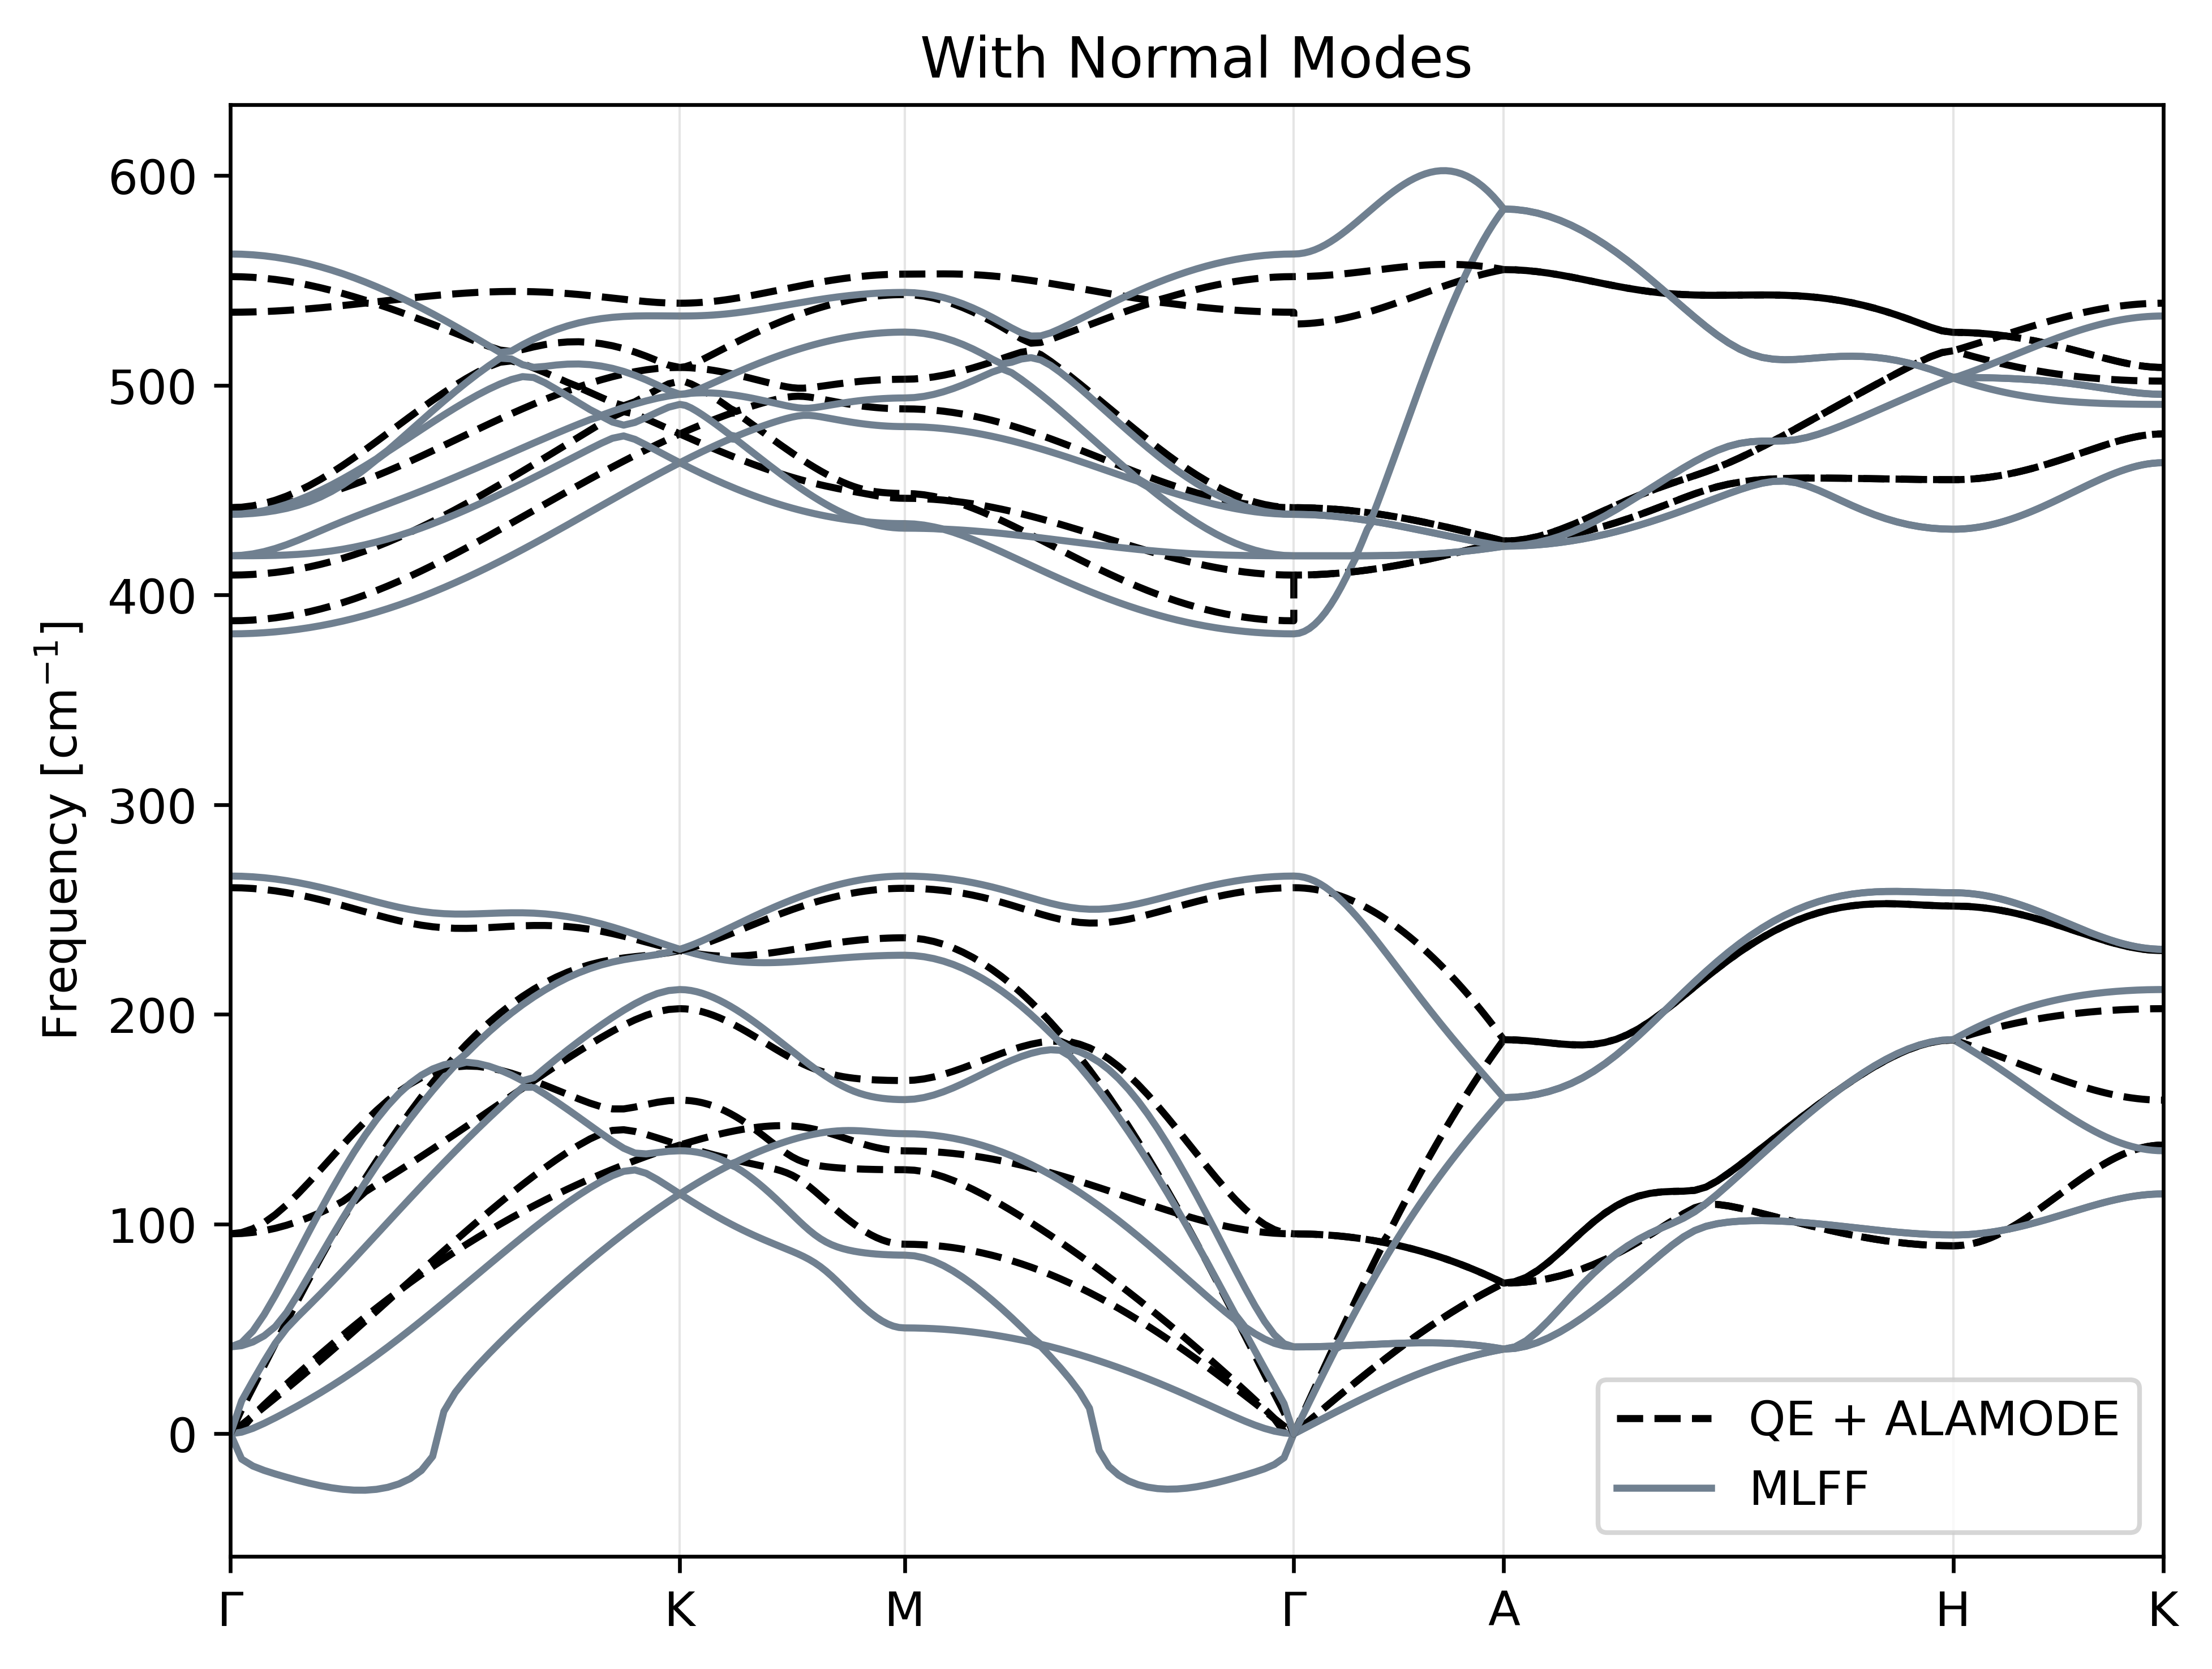

In [6]:
_, _, _, bands3 = read_bands(
    r"../alamode_phonons/03_mlff_aenetpytorch/LDA/model002/zno_lda_aenet.bands"
)

formatted_labels = [r"$\Gamma$" if label == "G" else label for label in labels1]
NBANDS = bands1.shape[1]

fig, ax = plt.subplots(dpi=600, layout="constrained")
ax.set_title("With Normal Modes")
ax.set(
    xticks=points1,
    xticklabels=labels,
    xlim=(points1[0], points1[-1]),
    ylabel=r"Frequency [cm$^{-1}$]",
)

for q in range(NBANDS):
    label_dft = "QE + ALAMODE" if q == 0 else ""
    label_mlff = "MLFF" if q == 0 else ""

    ax.plot(x1, bands1[:, q], color="black", ls="--", label=label_dft)
    ax.plot(x1, bands2[:, q], color="slategray", ls="-", label=label_mlff)

for p in points1:
    plt.axvline(p, color="gray", linestyle="-", lw=0.5, alpha=0.2)
ax.legend()
plt.show()